# Image Segmentation and Clustering

Segmentation asks one question: given nothing but pixel values, which pixels belong together? This notebook answers it three ways, the same three the lecture covers, and shows where each answer breaks:

1. **Cluster the colors**: K-means and mean shift treat every pixel as a point in color space.
2. **Flood a landscape**: watershed treats brightness or distance as height and floods it from markers.
3. **Cut a graph**: GrabCut treats pixels as nodes and cuts where neighbors are least alike.

It closes with SLIC superpixels, which are K-means again, restricted to small neighborhoods. Every example uses a photo from the `data/` folder.

In [1]:
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt


def show(images, titles, figsize=(15, 5)):
    # Show images side by side. Color images must already be RGB.
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    for ax, im, title in zip(np.atleast_1d(axes), images, titles):
        ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## K-Means Clustering

Image segmentation using K-Means involves clustering the pixels of the image based on their colors. This often results in an image where different regions are represented by different colors, indicating different segments or clusters.

Here's a step-by-step plan of how we'll achieve this:

- Load the image using OpenCV.
- Convert the image from BGR to RGB (as OpenCV loads images in BGR format).
- Flatten the image to get all the pixels.
- Apply K-Means clustering to cluster the pixels based on color.
- Reshape the flattened image back to its original shape.
- Display the segmented image.

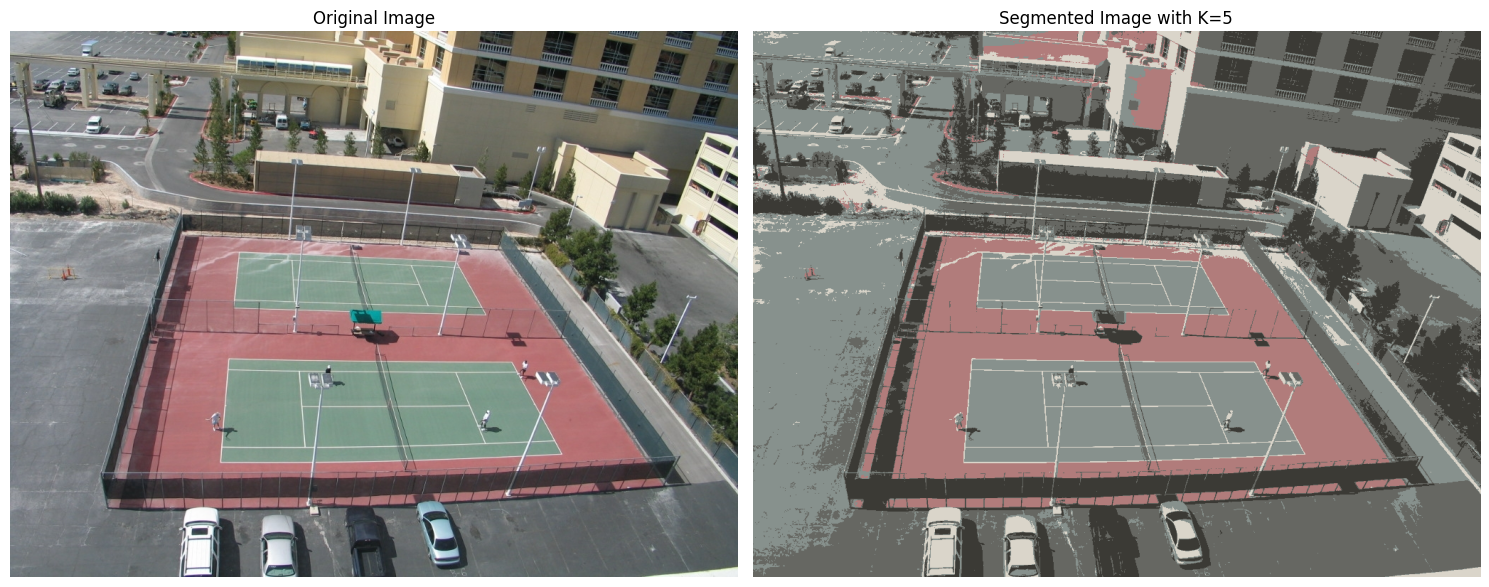

In [2]:
# Load the image
img = cv2.imread('data/tennis_court2.jpg')

# Convert the image from BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Flatten the image: one row per pixel, one column per channel
pixels = img_rgb.reshape((-1, 3)).astype(np.float32)

# Apply K-Means clustering
k = 5  # Number of clusters
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
cv2.setRNGSeed(0)  # the random starting centers are the same on every run
compactness, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Convert centers to integers
centers = np.uint8(centers)

# Map the labels to the centers, then reshape back to the image's shape
segmented_image = centers[labels.flatten()].reshape(img_rgb.shape)

show([img_rgb, segmented_image], ['Original Image', f'Segmented Image with K={k}'], figsize=(15, 6))

### K-Means Clustering Parameters

The `cv2.kmeans` function is called as follows:
```python
compactness, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
```
Here is a breakdown of its parameters, with reference to the values used in the code:

1.  `data`: `pixels`
    - The input data for clustering. It must be of type `np.float32`, with one row per data point and one feature per column.
2.  `K`: `k` (set to 5)
    - The desired number of clusters.
3.  `bestLabels`: `None`
    - This is an output parameter. When `None` is passed, OpenCV allocates an array that will be filled with the cluster index for each data point.
4.  `criteria`: `(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)`
    - The termination criteria for the iterative algorithm. The algorithm stops when either of the following conditions is met:
        - `cv2.TERM_CRITERIA_MAX_ITER`: A maximum of **100** iterations is reached.
        - `cv2.TERM_CRITERIA_EPS`: The cluster centers move by less than **0.2**.
5.  `attempts`: `10`
    - The number of times the K-Means algorithm is run with different initial centroid selections. The result returned is the one with the best compactness.
6.  `flags`: `cv2.KMEANS_RANDOM_CENTERS`
    - Specifies how the initial cluster centers are chosen. In this case, they are selected randomly from the data points. `cv2.KMEANS_PP_CENTERS` uses K-means++, which spreads the starting centers out.

The three return values are the **compactness** (the sum of squared distances from every pixel to its center, the quantity K-means minimizes), the **labels** (one cluster index per pixel), and the **centers** (one mean color per cluster).

`cv2.setRNGSeed(0)` fixes OpenCV's random number generator, so the random starting centers, and therefore the result, are the same every time the cell runs.

### What Got Merged?

Look at the segmented image again: both green tennis courts turned the same gray as the parking lot. The printout below shows why. K-means only knows distances between colors, and in RGB the pale green of the court is closer to the gray asphalt than either is to the red court surface.

In [3]:
label_map = labels.reshape(img_rgb.shape[:2])
court, asphalt = (520, 450), (700, 60)   # (row, col) of one court pixel and one asphalt pixel

print('cluster centers (RGB):', centers.tolist())
print('court pixel  ', img_rgb[court].tolist(), '-> cluster', label_map[court])
print('asphalt pixel', img_rgb[asphalt].tolist(), '-> cluster', label_map[asphalt])
print('distance court to asphalt: %.1f' % np.linalg.norm(img_rgb[court].astype(float) - img_rgb[asphalt]))

cluster centers (RGB): [[102, 103, 98], [135, 145, 141], [59, 58, 53], [218, 213, 202], [177, 124, 123]]
court pixel   [134, 158, 144] -> cluster 1
asphalt pixel [119, 122, 127] -> cluster 1
distance court to asphalt: 42.5


### Choosing K

Compactness always goes down as K goes up, because more centers can only sit closer to the pixels. It reaches zero when every distinct color has its own center. So compactness alone cannot choose K: what matters is where adding a cluster stops buying much.

In [4]:
for k_try in (2, 3, 5, 8, 12):
    cv2.setRNGSeed(0)
    comp, _, _ = cv2.kmeans(pixels, k_try, None, criteria, 3, cv2.KMEANS_PP_CENTERS)
    print(f'K = {k_try:2d}   compactness = {comp:.3e}')

K =  2   compactness = 2.040e+09
K =  3   compactness = 1.124e+09
K =  5   compactness = 5.269e+08
K =  8   compactness = 2.879e+08
K = 12   compactness = 1.962e+08


### Adding Position to the Features

Color alone lets one cluster be scattered all over the image. Adding each pixel's `(x, y)` coordinates to its feature vector makes nearby pixels more alike, which encourages compact segments.

There is a trap. K-means measures plain Euclidean distance, so a feature with a larger range counts for more. The colors run from 0 to 255, but `x` runs from 0 to 1023 here. With raw coordinates, position swamps color and K-means cuts the photo into blocks. Scaling the coordinates first, here so that they run from 0 to 128, lets both count.

The printout measures how uniform each cluster's color is: the average standard deviation of the RGB values inside a cluster. Lower means more uniform color.

color only                 average color spread inside a cluster:  15.7
color + raw (x, y)         average color spread inside a cluster:  43.5
color + (x, y) * 128 / w   average color spread inside a cluster:  18.3


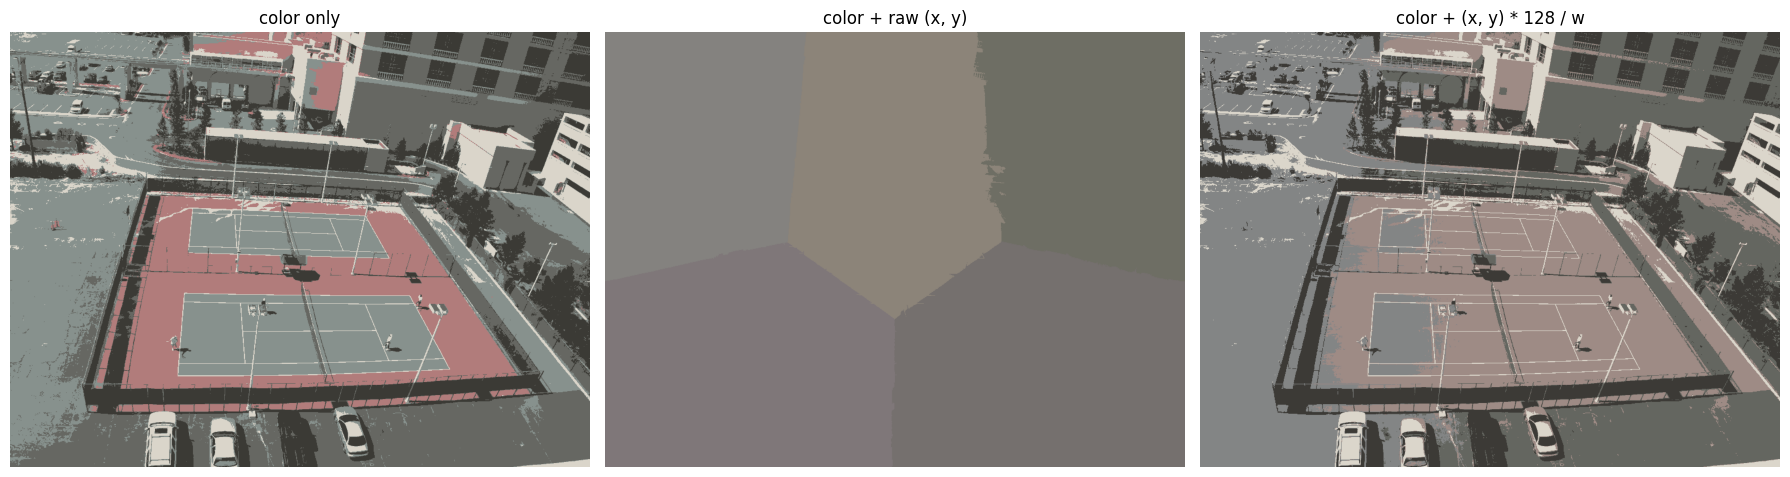

In [5]:
h, w = img_rgb.shape[:2]
yy, xx = np.mgrid[0:h, 0:w]
xy = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

variants = {
    'color only': pixels,
    'color + raw (x, y)': np.hstack([pixels, xy]),
    'color + (x, y) * 128 / w': np.hstack([pixels, xy * 128 / w]),
}

results = []
for name, feat in variants.items():
    cv2.setRNGSeed(0)
    _, lab, _ = cv2.kmeans(feat, 5, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    lab = lab.ravel()
    # paint each cluster with the mean color of its pixels
    means = np.array([pixels[lab == j].mean(axis=0) for j in range(5)])
    results.append(np.uint8(means)[lab].reshape(img_rgb.shape))
    spread = np.mean([pixels[lab == j].std(axis=0).mean() for j in range(5)])
    print(f'{name:26s} average color spread inside a cluster: {spread:5.1f}')

show(results, list(variants), figsize=(18, 5))

## Mean Shift Algorithm

The Mean Shift algorithm is a non-parametric clustering technique that can be applied to image segmentation. It works by iteratively shifting points to the mode (densest region) of a distribution. For image segmentation, Mean Shift considers the spatial and color information of the image.

The process typically involves:

- Convert the image to the CIE L\*u\*v\* color space (Mean Shift often performs better in this space than in RGB).
- Apply Mean Shift filtering.
- Display the results.

**Note:** CIE L\*u\*v\* is a color space defined by the International Commission on Illumination (abbreviated as CIE for its French name, Commission Internationale de l'Éclairage). Like its sibling CIE L\*a\*b\*, it is designed to be close to perceptually uniform: a given Euclidean distance between two colors looks like roughly the same amount of difference anywhere in the space.

Here's a breakdown of its components:

1. **L\*** (Lightness):
    - Represents the lightness of the color, from 0 (black) to 100 (white).

2. **u\*** (roughly green to red):
    - Positive values move toward red, negative values toward green.

3. **v\*** (roughly blue to yellow):
    - Positive values move toward yellow, negative values toward blue.

Mean shift decides everything by distance in color space: which pixels fall inside the color window, and where the window moves next. That is why a perceptually uniform space matters here. In RGB, the same numeric distance can be an obvious difference in one part of the space and an invisible one in another.

OpenCV stores 8-bit L\*u\*v\* images rescaled to 0 to 255 in every channel, so the color radius `sr` below is measured in those 8-bit units.

pyrMeanShiftFiltering took 2.7 s


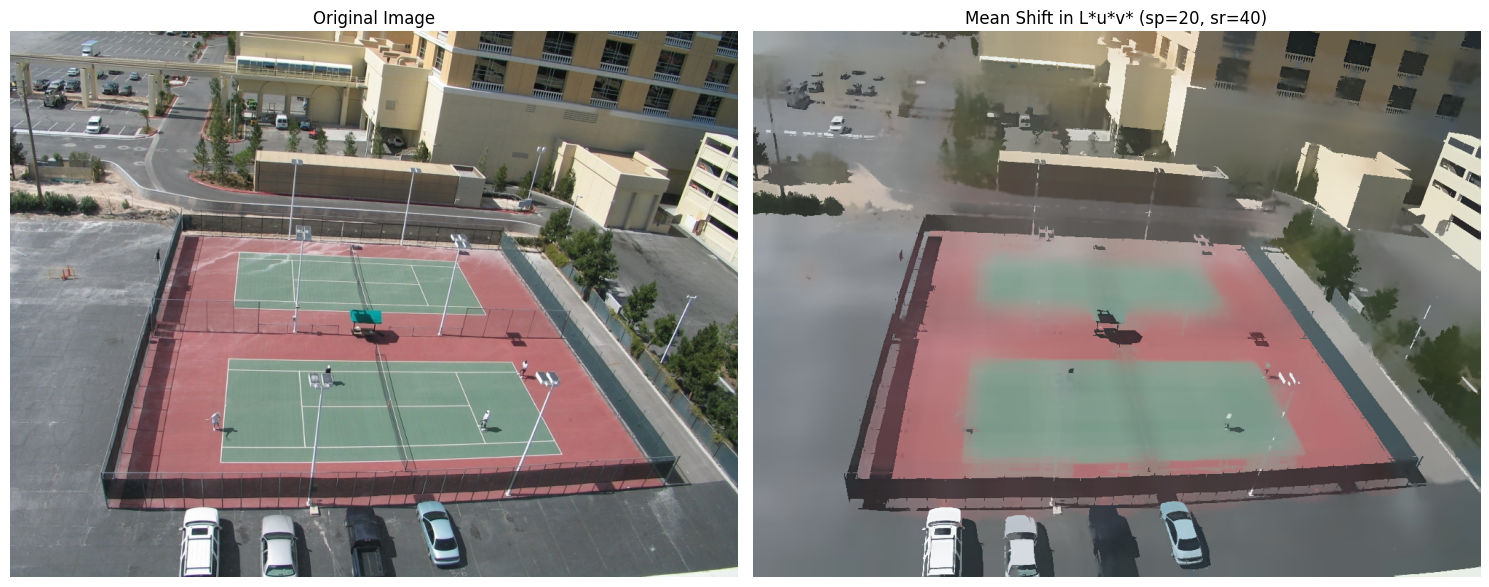

In [6]:
# Load the image
img = cv2.imread('data/tennis_court2.jpg')

# Convert the image to the L*u*v* color space
img_luv = cv2.cvtColor(img, cv2.COLOR_BGR2Luv)

# Define the spatial window radius 'sp' and color window radius 'sr'
sp = 20
sr = 40

# Apply Mean Shift filtering in L*u*v*
start = time.time()
shifted = cv2.pyrMeanShiftFiltering(img_luv, sp, sr)
print(f'pyrMeanShiftFiltering took {time.time() - start:.1f} s')

# Convert the result back to RGB for display
mean_shift_result_rgb = cv2.cvtColor(shifted, cv2.COLOR_Luv2RGB)

show([cv2.cvtColor(img, cv2.COLOR_BGR2RGB), mean_shift_result_rgb],
     ['Original Image', f'Mean Shift in L*u*v* (sp={sp}, sr={sr})'], figsize=(15, 6))

### Mean Shift Filtering Parameters

The `cv2.pyrMeanShiftFiltering` function is called as follows:
```python
shifted = cv2.pyrMeanShiftFiltering(img_luv, sp, sr)
```
Here is a breakdown of its parameters, with reference to the values used in the code:

1.  `src`: `img_luv`
    - The input image, which must be an 8-bit, 3-channel image. The function works on whatever the three channels contain, so the color space is your choice, made by the conversion before the call.

2.  `sp`: `20`
    - The spatial window radius. This parameter defines the radius of the search window in the spatial domain. A larger value will mean that more distant pixels are considered in the mean shift calculation, potentially leading to larger segments but also slower performance.

3.  `sr`: `40`
    - The color window radius. This parameter defines the radius of the search window in the color domain. A larger value will cause colors that are further apart to be grouped into the same segment, leading to fewer, more dominant color regions.

4.  `maxLevel` (optional, default `1`) and `termcrit` (optional, default at most **5** iterations, or a shift smaller than 1)
    - `maxLevel` runs the procedure on a small image pyramid first to save time. `termcrit` stops each pixel's climb after at most 5 steps by default, so pixels that belong to one mode end up with nearly, not exactly, the same color.

For each pixel, the algorithm considers the pixels within `sp` of it in position and within `sr` of it in color, computes their mean position and mean color, and moves the window there. It repeats this until the window stops moving or `termcrit` says stop, then gives the original pixel the color where its window ended.

### Counting the Segments

`pyrMeanShiftFiltering` returns a **smoothed image, not a label map**. To get segments you still have to group the pixels that ended at the same mode. Counting unique colors does not do that: the filtered image still has tens of thousands of distinct colors, because each climb stops after at most 5 steps.

The cell below labels **connected regions of (almost) equal color** with a flood fill, the approach OpenCV's own mean shift segmentation sample uses. A tolerance of 1 per channel is deliberately strict: looser tolerances let a fill creep across a slow color gradient and swallow neighboring regions.

In [7]:
def region_sizes(image, tol=1):
    # Flood-fill from every pixel no earlier fill has reached; return the region sizes, largest first.
    h, w = image.shape[:2]
    mask = np.zeros((h + 2, w + 2), np.uint8)    # floodFill needs a 1-pixel border
    sizes = []
    for y in range(h):
        for x in np.flatnonzero(mask[y + 1, 1:-1] == 0):
            if mask[y + 1, x + 1] == 0:
                area, *_ = cv2.floodFill(image, mask, (int(x), int(y)), 0, (tol,) * 3, (tol,) * 3,
                                         4 | cv2.FLOODFILL_MASK_ONLY | (255 << 8))
                sizes.append(area)
    return np.sort(np.array(sizes))[::-1]


print('distinct colors in the input:  ', len(np.unique(img.reshape(-1, 3), axis=0)))
print('distinct colors after filtering:', len(np.unique(shifted.reshape(-1, 3), axis=0)))

sizes = region_sizes(shifted)
covering = int(np.searchsorted(np.cumsum(sizes) / sizes.sum(), 0.9)) + 1
print(f'regions: {len(sizes)}')
print(f'regions of at least 100 pixels: {(sizes >= 100).sum()}')
print(f'the largest {covering} regions cover 90% of the image')

distinct colors in the input:   97482
distinct colors after filtering: 20575
regions: 33760
regions of at least 100 pixels: 188
the largest 172 regions cover 90% of the image


So the answer to "how many segments did mean shift find?" is a few hundred large regions that carry almost the whole image, plus tens of thousands of specks along edges and in texture. Deciding which specks to merge into their neighbors is a further step that real segmentation pipelines add.

### Changing sp and sr

Try other window sizes. A larger `sr` merges more colors, a larger `sp` lets each window see farther, and both change the running time a lot.

In [8]:
for sp_try, sr_try in [(20, 20), (20, 40), (20, 60), (10, 40), (40, 40)]:
    start = time.time()
    out = cv2.pyrMeanShiftFiltering(img_luv, sp_try, sr_try)
    elapsed = time.time() - start
    s = region_sizes(out)
    print(f'sp={sp_try:2d} sr={sr_try:2d}   {elapsed:4.1f} s   regions of 100+ pixels: {(s >= 100).sum():4d}')

sp=20 sr=20    5.3 s   regions of 100+ pixels:  282
sp=20 sr=40    2.8 s   regions of 100+ pixels:  188
sp=20 sr=60    1.1 s   regions of 100+ pixels:  106
sp=10 sr=40    0.6 s   regions of 100+ pixels:  214
sp=40 sr=40   10.5 s   regions of 100+ pixels:  190


## Watershed Algorithm

The Watershed algorithm is a classic image segmentation method based on topography. It works by viewing a grayscale image as a topographic surface where light pixels are high elevations and dark pixels are low elevations. The algorithm then floods this surface from its minima and builds barriers (watershed lines) where water from different sources meets.

Flooded from every local minimum, a real photo shatters into thousands of regions, because noise and texture create minima everywhere. The fix is to flood only from **markers**: areas that are sure to be one object or the background. The quality of the segmentation depends almost entirely on the markers.

This section first shows what goes wrong when the markers are in the wrong place, then builds good markers with the distance transform.

### A Cautionary Example: Markers on the Edges

The next cell tries to find markers from the gradient magnitude of the tennis court photo. The idea sounds right: objects are flat inside, so their gradient is low, and the minima of the gradient should mark their interiors.

The code does something else. `gradient - opening(gradient)` is a *top-hat* transform, which keeps the small **bright** details of the gradient: its strongest, thinnest edges, not its minima. Otsu then keeps the brightest of those. So every marker sits on an edge, which is exactly where a marker should never be, and the result is the over-segmentation problem itself.

mean gradient at the marker pixels: 84.1
mean gradient over the whole image: 16.6
markers: 2602   regions after flooding: 2593


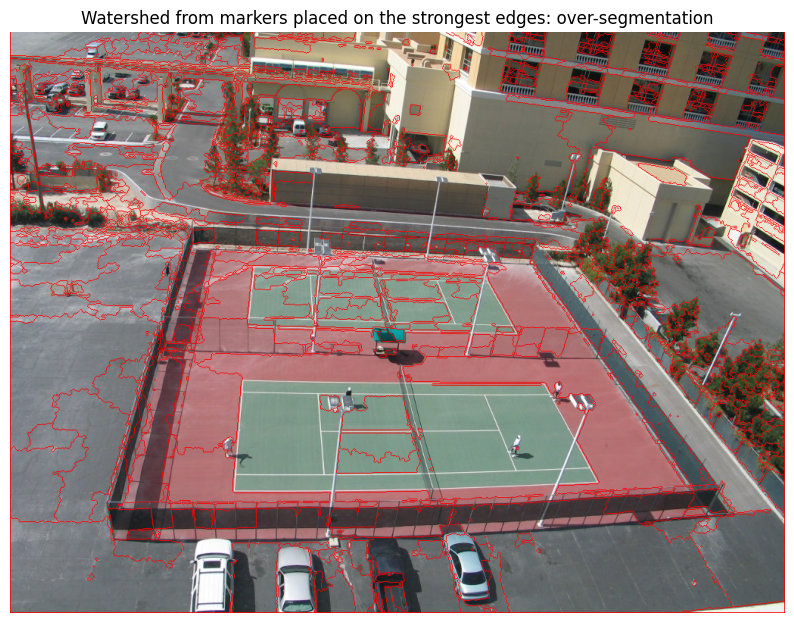

In [9]:
# Load the image
img = cv2.imread('data/tennis_court2.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Calculate the gradient magnitude
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)

# Convert the gradient magnitude to 8-bit
gradient_magnitude_8bit = np.uint8(255 * gradient_magnitude / gradient_magnitude.max())

# Opening removes small bright details; subtracting it keeps ONLY those details (a top-hat)
opened = cv2.morphologyEx(gradient_magnitude_8bit, cv2.MORPH_OPEN, kernel=np.ones((5, 5), np.uint8))
top_hat = gradient_magnitude_8bit - opened

# Threshold to a binary image to get markers
_, marker_mask = cv2.threshold(top_hat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print('mean gradient at the marker pixels: %.1f' % gradient_magnitude_8bit[marker_mask > 0].mean())
print('mean gradient over the whole image: %.1f' % gradient_magnitude_8bit.mean())

# Label the markers
n_markers, markers = cv2.connectedComponents(marker_mask)
markers = markers.astype(np.int32)

# Apply the Watershed algorithm
cv2.watershed(img, markers)
print('markers:', n_markers - 1, '  regions after flooding:', len(np.unique(markers)) - 1)

# Mark watershed boundaries in red (BGR order)
img[markers == -1] = [0, 0, 255]

# Convert the result back to RGB for display
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Watershed from markers placed on the strongest edges: over-segmentation')
plt.axis('off')
plt.show()

### Watershed Algorithm Parameters

The `cv2.watershed` function is called as follows:
```python
cv2.watershed(img, markers)
```
Here is a breakdown of its parameters, with reference to the values used in the code:

1.  `image`: `img`
    - This is the input image for segmentation. It must be an 8-bit, 3-channel image (like a standard color image).

2.  `markers`: `markers`
    - This is a critical input/output parameter. It is a single-channel, 32-bit integer array (`np.int32`) of the same size as the input image.
    - **On input**, it contains the initial markers for different regions.
        - Pixels with a value of `0` are considered "unknown" and are the ones the algorithm will segment.
        - Pixels with positive integer values (`1`, `2`, `3`, etc.) are treated as seeds for different regions. These are the starting points for the "flooding" process.
    - **On output**, the `markers` array is modified in place:
        - The "unknown" pixels (`0`) are assigned the label of the region they belong to.
        - Pixels at the boundaries between regions (the watershed lines) are marked with `-1`.

In the cell above, `cv2.connectedComponents` gave every pixel that is *not* a marker the label `0`, so all of them were "unknown", and each of the thousands of small marker blobs grew its own region.

### Markers From the Distance Transform

Watershed earns its place on **touching objects**, which a threshold alone merges into one blob. None of the photos in `data/` has touching objects, so the next cell draws three overlapping disks: after thresholding they are a single white blob, and the goal is to recover three objects.

The pipeline:

- **Sure background**: dilate the mask a little. Anything outside the dilated mask is certainly background.
- **Sure foreground**: the distance transform gives every white pixel its distance to the nearest black pixel. That distance peaks once in the middle of each disk, even where the disks overlap, so keeping only pixels far from the edge leaves one blob per disk.
- **Unknown**: the band between the two, which the flooding decides.

blobs after thresholding: 1
regions found (not counting the background): 3


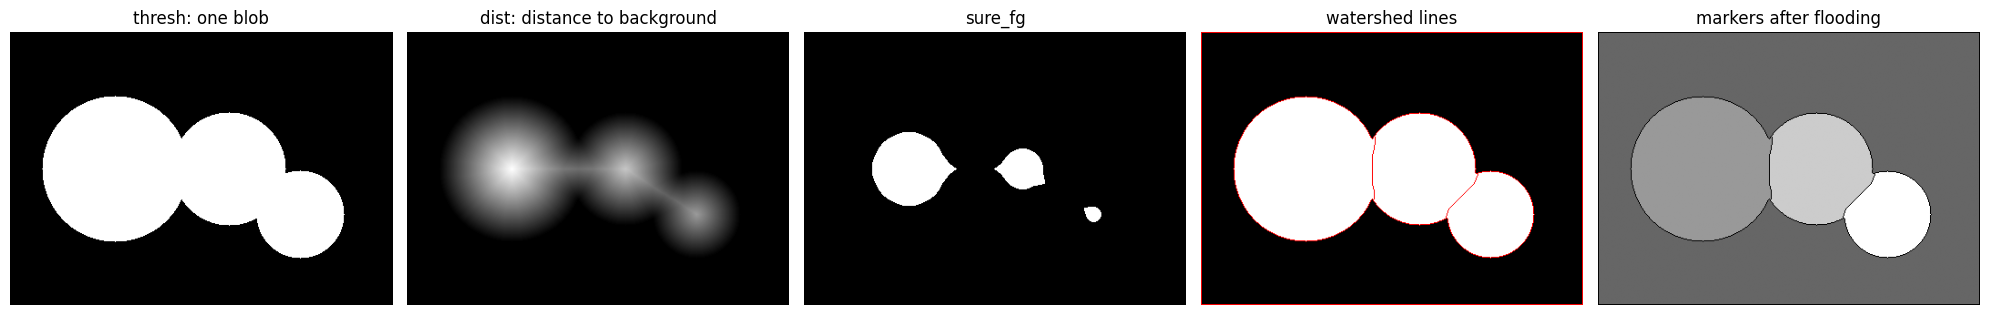

In [10]:
# Three overlapping disks: one blob after thresholding, three objects to find
img = np.zeros((300, 420, 3), np.uint8)
for (x, y, r) in [(115, 150, 80), (240, 150, 62), (318, 200, 48)]:
    cv2.circle(img, (x, y), r, (255, 255, 255), -1)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print('blobs after thresholding:', cv2.connectedComponents(thresh)[0] - 1)

# Sure background: everything a little beyond the mask
sure_bg = cv2.dilate(thresh, np.ones((3, 3), np.uint8), iterations=3)

# Sure foreground: pixels far from any edge, i.e. the middle of each disk
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Unknown: the band in between, which the flooding will decide
unknown = cv2.subtract(sure_bg, sure_fg)

# One integer label per sure-foreground blob; background becomes 1, not 0
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0          # 0 means: let the flood decide

cv2.watershed(img, markers)          # fills markers in place; ridges become -1
print('regions found (not counting the background):', len(set(np.unique(markers)) - {-1, 1}))

result = img.copy()
result[markers == -1] = [0, 0, 255]  # BGR order, so this is red

show([thresh, dist, sure_fg, cv2.cvtColor(result, cv2.COLOR_BGR2RGB), markers],
     ['thresh: one blob', 'dist: distance to background', 'sure_fg', 'watershed lines', 'markers after flooding'],
     figsize=(20, 4))

### How Far From the Edge Is "Sure"?

The sure-foreground threshold is a fraction of the *largest* distance in the image. Too low, and the overlapping disks still touch, so they share one marker. Too high, and a small disk never gets far enough from its edge to keep a marker at all. Many tutorials use 0.7; try it.

In [11]:
for frac in (0.3, 0.4, 0.5, 0.6, 0.7, 0.8):
    _, fg = cv2.threshold(dist, frac * dist.max(), 255, 0)
    fg = np.uint8(fg)
    n, m = cv2.connectedComponents(fg)
    m = m + 1
    m[cv2.subtract(sure_bg, fg) == 255] = 0
    cv2.watershed(img, m)
    print(f'threshold {frac:.1f} x max distance: {n - 1} markers, {len(set(np.unique(m)) - {-1, 1})} regions')

threshold 0.3 x max distance: 1 markers, 1 regions
threshold 0.4 x max distance: 2 markers, 2 regions
threshold 0.5 x max distance: 3 markers, 3 regions
threshold 0.6 x max distance: 3 markers, 3 regions
threshold 0.7 x max distance: 2 markers, 2 regions
threshold 0.8 x max distance: 1 markers, 1 regions


The disks have radii 80, 62 and 48, and the largest distance in the image is about 79. Any fraction above 48 / 79, about 0.6, erases the smallest disk's marker, so 0.7 finds two objects. A single fraction of the maximum is the wrong tool when objects differ in size; one fix is to look for local maxima of the distance instead of thresholding it globally.

## GrabCut: Segmentation as a Graph Cut

GrabCut treats the image as a graph. Every pixel is a node, linked to its neighbors and to two extra nodes: a *source* standing for foreground and a *sink* standing for background.

- The links to the source and the sink carry the **cost of giving the pixel a label**: how poorly its color fits the foreground or background color model.
- The links between neighbors carry the **cost of splitting them**: high for similar neighbors, low across a strong edge.

The minimum cut that separates source from sink labels every pixel at once. GrabCut starts its color models from a box drawn by the user, cuts, re-estimates the models from the result, and cuts again.

`cv2.grabCut` works on a `mask` with four values: `cv2.GC_BGD` (0, sure background), `cv2.GC_FGD` (1, sure foreground), `cv2.GC_PR_BGD` (2, probably background) and `cv2.GC_PR_FGD` (3, probably foreground). Starting from a box, everything outside the box is sure background and everything inside is probably foreground.

foreground pixels from the box: 8851   tail patch kept: 0%
foreground pixels after the stroke: 10115   tail patch kept: 87%


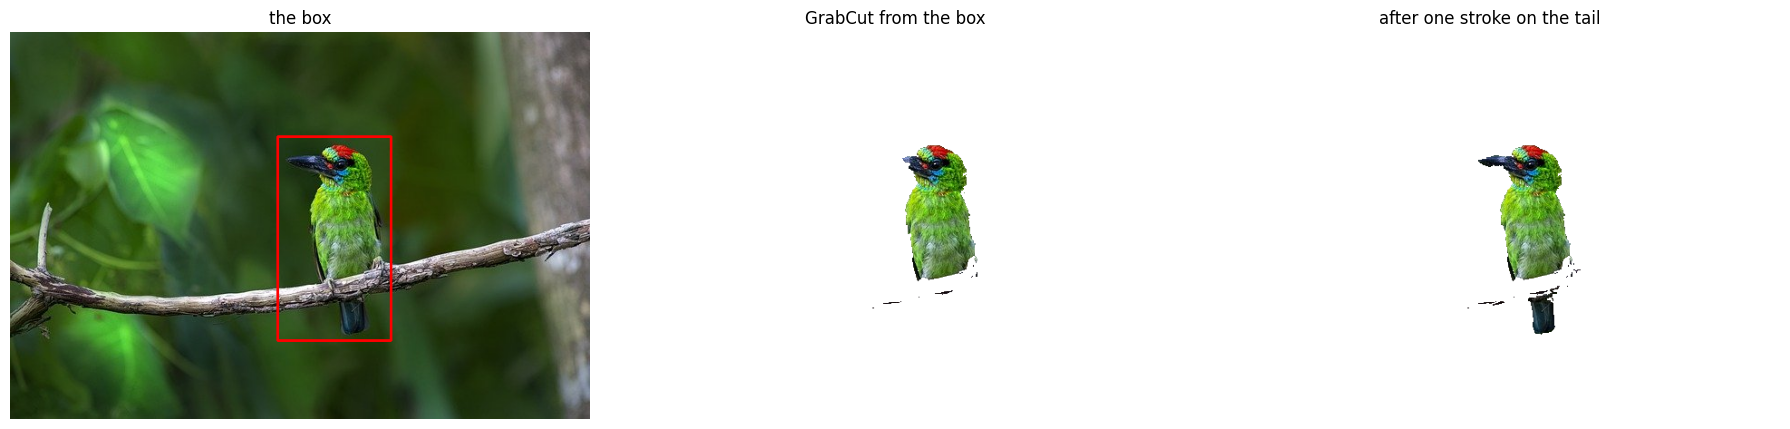

In [12]:
img = cv2.imread('data/red-throated-barbet.jpg')
mask = np.zeros(img.shape[:2], np.uint8)
bgd, fgd = np.zeros((1, 65)), np.zeros((1, 65))   # color models GrabCut fills in
rect = (295, 115, 125, 225)                        # the box: x, y, width, height

cv2.setRNGSeed(0)
cv2.grabCut(img, mask, rect, bgd, fgd, 5, cv2.GC_INIT_WITH_RECT)
fg_box = (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD)

tail = (slice(295, 330), slice(365, 392))          # a patch on the bird's tail, below the branch
print('foreground pixels from the box:', fg_box.sum(), '  tail patch kept: %.0f%%' % (100 * fg_box[tail].mean()))

# One stroke of sure foreground on the tail, then refine from the mask
cv2.line(mask, (377, 300), (378, 326), cv2.GC_FGD, 6)
cv2.grabCut(img, mask, None, bgd, fgd, 5, cv2.GC_INIT_WITH_MASK)
fg = (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD)
print('foreground pixels after the stroke:', fg.sum(), '  tail patch kept: %.0f%%' % (100 * fg[tail].mean()))

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
boxed = rgb.copy()
x, y, w, h = rect
cv2.rectangle(boxed, (x, y), (x + w, y + h), (255, 0, 0), 2)   # RGB here, so this is red
white = np.full_like(rgb, 255)
show([boxed, np.where(fg_box[..., None], rgb, white), np.where(fg[..., None], rgb, white)],
     ['the box', 'GrabCut from the box', 'after one stroke on the tail'], figsize=(18, 5))

The first cut follows the branch and drops the tail. The branch is a strong edge, and cutting between very different neighbors is cheap, while the dark tail looks more like the dark background than like the green bird. One stroke of sure foreground changes the cost of that choice, and the second cut keeps the tail. This is exactly how interactive tools use GrabCut: a box first, then a few strokes where it went wrong.

## Superpixels with SLIC

Superpixels deliberately over-segment an image into a few hundred compact regions of similar color, which later steps can treat as units instead of a million pixels. The standard algorithm, SLIC (Simple Linear Iterative Clustering), is K-means on color plus position, with two changes: the centers start on a regular grid, and each center only searches a small window around itself, which makes it fast.

`skimage.segmentation.slic` expects an RGB image. `n_segments` is roughly how many superpixels you want, and `compactness` trades color against position, exactly the scaling question from the K-means section: a higher value makes squarer superpixels that follow edges less.

compactness  5: 170 superpixels in 0.9 s
compactness 30: 293 superpixels in 0.9 s


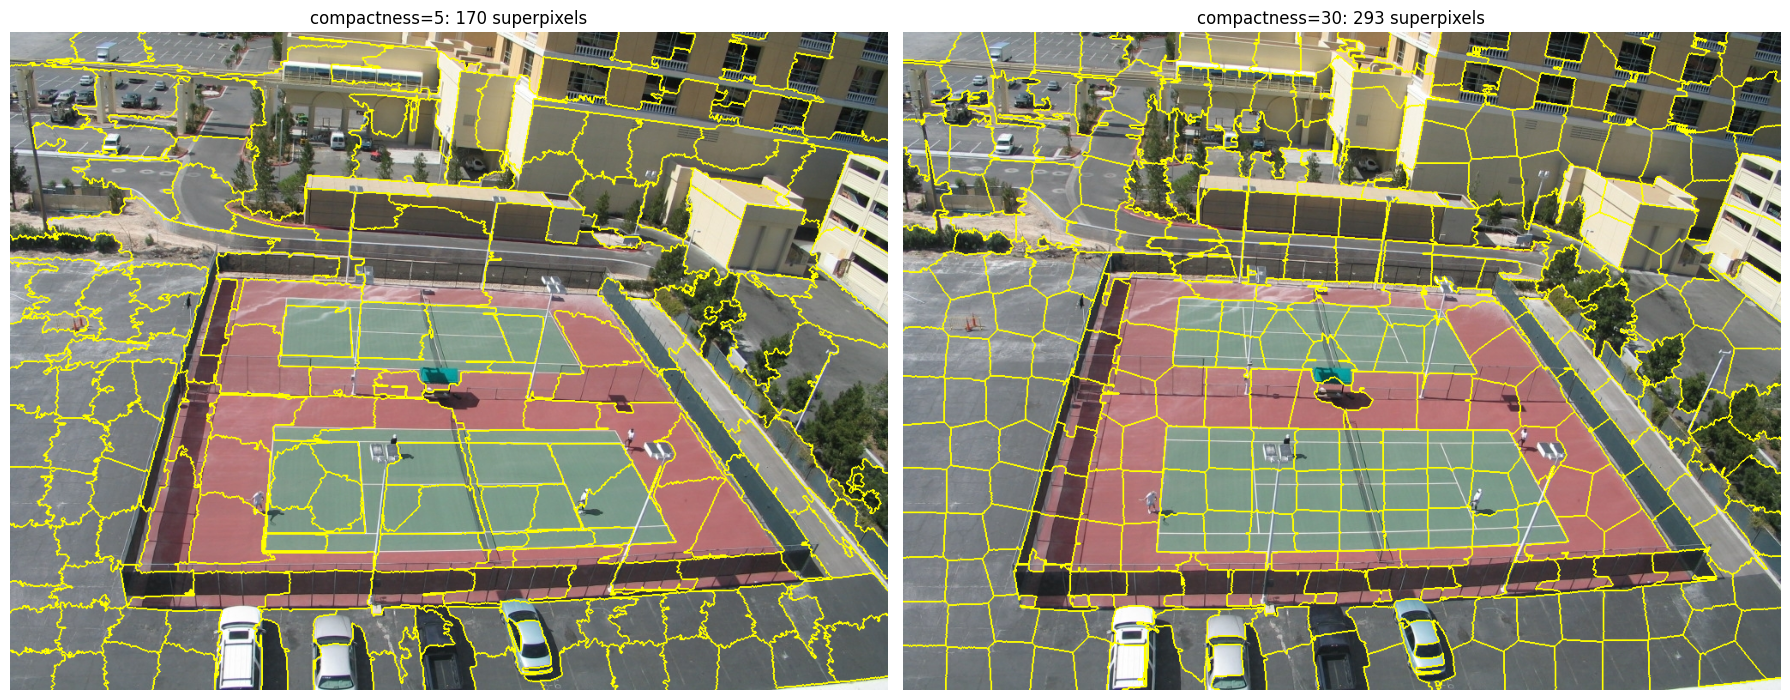

In [13]:
from skimage.segmentation import slic, mark_boundaries

img_rgb = cv2.cvtColor(cv2.imread('data/tennis_court2.jpg'), cv2.COLOR_BGR2RGB)

panels, titles = [], []
for compactness in (5, 30):
    start = time.time()
    segments = slic(img_rgb, n_segments=300, compactness=compactness, start_label=1)
    elapsed = time.time() - start
    panels.append(mark_boundaries(img_rgb, segments, color=(1, 1, 0)))
    titles.append(f'compactness={compactness}: {segments.max()} superpixels')
    print(f'compactness {compactness:2d}: {segments.max()} superpixels in {elapsed:.1f} s')

show(panels, titles, figsize=(18, 7))

## Summary

| Method | You choose | It breaks when |
|---|---|---|
| K-means | K, the features, and how they are scaled | different objects share a color, or one feature's range swamps the rest |
| Mean shift | the window radii `sp` and `sr` | the radii are wrong for the image; it is also slow |
| Watershed | the markers | markers land on edges, or a single threshold misses small objects |
| GrabCut | a box, then strokes | a strong edge runs through the object, or it looks like the background |
| SLIC | the number of superpixels and the compactness | you need whole objects: superpixels are pieces by design |